# EndekGAN-T2I Dataset Method Analysis Notebook

Notebook ini khusus untuk bagian **Dataset** pada paper:

**EndekGAN-T2I: An Expert-Guided Text-to-Image Conditional GAN Baseline for Balinese Endek Textile Motif Generation**

Notebook ini menghasilkan bahan untuk subbagian **Method — Dataset**:
1. Validasi struktur dataset.
2. Pemeriksaan gambar rusak.
3. Pemeriksaan duplikasi MD5.
4. Ringkasan distribusi kelas.
5. Ringkasan ukuran citra.
6. Pembuatan `metadata_expert_guided.csv`.
7. Pembuatan prompt text-to-image berbasis pengetahuan pakar Endek.
8. Split train/validation/test.
9. Export tabel dan gambar untuk paper.

Dataset utama:

```text
D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset
```


In [1]:
# ============================================================
# 0. Optional package installation
# ============================================================
# Jalankan hanya jika package belum tersedia.
# !pip install pandas numpy matplotlib pillow scikit-learn openpyxl


In [2]:
# ============================================================
# 1. Import library and global configuration
# ============================================================
import os
import json
import random
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

try:
    from sklearn.model_selection import train_test_split
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

ImageFile.LOAD_TRUNCATED_IMAGES = True

DATASET_ROOT = Path(r"D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset")

CLASS_NAMES = ["flora", "fauna", "dekoratif", "geometris"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = DATASET_ROOT / f"dataset_method_outputs_{RUN_ID}"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for p in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, METADATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Dataset root :", DATASET_ROOT)
print("Output dir   :", OUTPUT_DIR)
print("Classes      :", CLASS_NAMES)
print("Sklearn      :", SKLEARN_AVAILABLE)


Dataset root : D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset
Output dir   : D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013
Classes      : ['flora', 'fauna', 'dekoratif', 'geometris']
Sklearn      : True


In [3]:
# ============================================================
# 2. Helper functions
# ============================================================
def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS

def md5_file(path: Path, chunk_size: int = 8192) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def safe_relative_path(path: Path, root: Path) -> str:
    try:
        return str(path.relative_to(root)).replace("\\", "/")
    except Exception:
        return path.name

def verify_image(path: Path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img = img.convert("RGB")
            width, height = img.size
        return True, width, height, ""
    except Exception as e:
        return False, None, None, str(e)

def display_df(df, name=None, save_csv_path=None):
    if name:
        print(name)
    display(df)
    if save_csv_path is not None:
        df.to_csv(save_csv_path, index=False, encoding="utf-8")
        print("Saved:", save_csv_path)


## 3. Expert knowledge basis for Endek text-to-image prompt construction

Prompt pada metadata text-to-image tidak hanya dibuat berdasarkan label kelas, tetapi juga berbasis konsep desain Endek dari materi penilaian pakar, seperti teknik stilasi, deformasi, distorsi, pola tata letak, prinsip komposisi, serta weavability constraint.


In [4]:
# ============================================================
# 3. Expert knowledge base and prompt template
# ============================================================
ENDEK_KNOWLEDGE = {
    "techniques": {
        "stilasi": (
            "teknik stilasi, yaitu penggayaan bentuk asli menjadi ornamen dekoratif "
            "dengan tetap mempertahankan ciri utama objek sumber"
        ),
        "deformasi": (
            "teknik deformasi, yaitu penyederhanaan struktur dan proporsi bentuk asli "
            "menjadi bentuk baru yang lebih dekoratif"
        ),
        "distorsi": (
            "teknik distorsi, yaitu perubahan bentuk dengan penekanan atau pelebaran proporsi "
            "untuk menghasilkan karakter visual yang lebih ekspresif"
        ),
    },
    "layout_patterns": [
        "pola tunggal",
        "pola acak terkontrol",
        "pola ulang himpunan",
        "pola ulang menyeluruh",
    ],
    "composition_principles": [
        "proporsi seimbang",
        "keseimbangan visual",
        "irama repetitif",
        "kontras bentuk dan warna",
        "klimaks visual yang jelas",
        "kesatuan ornamen",
    ],
    "weavability_constraints": [
        "layak diterapkan pada proses ikat tenun Endek",
        "mempertimbangkan jarak antar ikatan minimal 0,5 cm agar warna celupan dapat masuk",
        "motif tetap terbaca pada skala benang",
        "struktur ornamen tidak terlalu rapat sehingga dapat diendekkan",
        "mempertahankan karakter tekstur tenun ikat tradisional",
    ],
    "color_styles": [
        "warna merah dan emas yang kontras",
        "warna hijau dan kuning yang harmonis",
        "warna biru, hitam, dan putih dengan kontras kuat",
        "warna coklat, krem, dan emas bernuansa tradisional",
        "warna cerah khas kain upacara Bali",
    ],
    "cultural_context": [
        "digunakan dalam konteks budaya Bali",
        "menjaga kesakralan dan kepantasan motif",
        "memadukan unsur lama dan unsur baru secara kreatif",
        "mengutamakan nilai estetika, fungsi, dan identitas lokal Endek Bali",
    ],
}

CLASS_MOTIF_SOURCES = {
    "flora": [
        "bunga kamboja sebagai simbol kesucian",
        "daun dan sulur tanaman tropis Bali",
        "bunga teratai sebagai simbol keindahan dan keseimbangan",
        "motif bunga lokal dengan kelopak berulang",
    ],
    "fauna": [
        "kupu-kupu sebagai simbol keindahan dan transformasi",
        "burung sebagai simbol harmoni alam",
        "ikan atau hewan air sebagai inspirasi alam tropis",
        "bentuk fauna yang distilasi menjadi ornamen dekoratif",
    ],
    "dekoratif": [
        "ornamen tradisional Bali dengan unsur hias klasik",
        "paduan garis, titik, sulur, dan ornamen pinggir",
        "kombinasi unsur lama dan unsur baru dalam ragam hias Endek",
        "hiasan dekoratif dengan komposisi simetris",
    ],
    "geometris": [
        "susunan garis dan bidang berulang",
        "pola segitiga, segi empat, dan bentuk simetris",
        "komposisi geometris ritmis dengan pengulangan teratur",
        "ornamen geometris berbasis struktur ikat tradisional",
    ],
}

def stable_choice(options, key):
    idx = int(hashlib.md5(str(key).encode("utf-8")).hexdigest(), 16) % len(options)
    return options[idx]

def build_expert_prompt(label, filename):
    label = str(label).lower().strip()
    key = f"{label}_{filename}"

    motif_source = stable_choice(CLASS_MOTIF_SOURCES.get(label, CLASS_MOTIF_SOURCES["dekoratif"]), key + "_source")
    technique = stable_choice(list(ENDEK_KNOWLEDGE["techniques"].keys()), key + "_technique")
    technique_desc = ENDEK_KNOWLEDGE["techniques"][technique]
    layout = stable_choice(ENDEK_KNOWLEDGE["layout_patterns"], key + "_layout")
    comp1 = stable_choice(ENDEK_KNOWLEDGE["composition_principles"], key + "_comp1")
    comp2 = stable_choice(ENDEK_KNOWLEDGE["composition_principles"], key + "_comp2")
    color_style = stable_choice(ENDEK_KNOWLEDGE["color_styles"], key + "_color")
    weavability = stable_choice(ENDEK_KNOWLEDGE["weavability_constraints"], key + "_weave")
    cultural = stable_choice(ENDEK_KNOWLEDGE["cultural_context"], key + "_cultural")

    title = f"Motif Endek {label.capitalize()} berbasis {motif_source}"
    prompt = (
        f"{title}. "
        f"Desain kain Endek Bali bertema {label} yang terinspirasi dari {motif_source}. "
        f"Motif dibuat menggunakan {technique_desc}. "
        f"Tata letak menggunakan {layout}, dengan {comp1}, {comp2}, dan kesatuan ornamen. "
        f"Pewarnaan memakai {color_style}. "
        f"Desain harus {weavability}, tetap mempertahankan tekstur tenun ikat tradisional, "
        f"dan {cultural}."
    )
    return {
        "title": title,
        "motif_source": motif_source,
        "technique": technique,
        "layout_pattern": layout,
        "composition": f"{comp1}; {comp2}; kesatuan ornamen",
        "color_style": color_style,
        "weavability_note": weavability,
        "cultural_context": cultural,
        "prompt": prompt,
    }

for c in CLASS_NAMES:
    print("=" * 100)
    print(c.upper())
    print(build_expert_prompt(c, f"{c}_example.jpg")["prompt"])


FLORA
Motif Endek Flora berbasis daun dan sulur tanaman tropis Bali. Desain kain Endek Bali bertema flora yang terinspirasi dari daun dan sulur tanaman tropis Bali. Motif dibuat menggunakan teknik stilasi, yaitu penggayaan bentuk asli menjadi ornamen dekoratif dengan tetap mempertahankan ciri utama objek sumber. Tata letak menggunakan pola tunggal, dengan proporsi seimbang, irama repetitif, dan kesatuan ornamen. Pewarnaan memakai warna merah dan emas yang kontras. Desain harus struktur ornamen tidak terlalu rapat sehingga dapat diendekkan, tetap mempertahankan tekstur tenun ikat tradisional, dan memadukan unsur lama dan unsur baru secara kreatif.
FAUNA
Motif Endek Fauna berbasis bentuk fauna yang distilasi menjadi ornamen dekoratif. Desain kain Endek Bali bertema fauna yang terinspirasi dari bentuk fauna yang distilasi menjadi ornamen dekoratif. Motif dibuat menggunakan teknik stilasi, yaitu penggayaan bentuk asli menjadi ornamen dekoratif dengan tetap mempertahankan ciri utama objek s

In [5]:
# ============================================================
# 4. Scan dataset folder
# ============================================================
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root tidak ditemukan: {DATASET_ROOT}")

folder_rows = []
image_rows = []

for label in CLASS_NAMES:
    class_dir = DATASET_ROOT / label
    folder_rows.append({
        "label": label,
        "folder_path": str(class_dir),
        "exists": class_dir.exists(),
        "is_dir": class_dir.is_dir() if class_dir.exists() else False,
    })
    if class_dir.exists() and class_dir.is_dir():
        for img_path in sorted(class_dir.rglob("*")):
            if is_image_file(img_path):
                image_rows.append({
                    "filename": safe_relative_path(img_path, DATASET_ROOT),
                    "image_path": str(img_path),
                    "label": label,
                    "class_idx": CLASS_TO_IDX[label],
                    "extension": img_path.suffix.lower(),
                })

folder_df = pd.DataFrame(folder_rows)
raw_df = pd.DataFrame(image_rows)

display_df(folder_df, "Folder validation:", TABLE_DIR / "folder_validation.csv")

raw_distribution = raw_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).rename_axis("label").reset_index(name="raw_count")
display_df(raw_distribution, "Raw image distribution:", TABLE_DIR / "raw_class_distribution.csv")

print("Total raw image files:", len(raw_df))


Folder validation:


,label,folder_path,exists,is_dir
0,flora,D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\Ende...,True,True
1,fauna,D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\Ende...,True,True
2,dekoratif,D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\Ende...,True,True
3,geometris,D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\Ende...,True,True


Saved: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\tables\folder_validation.csv
Raw image distribution:


,label,raw_count
0,flora,148
1,fauna,54
2,dekoratif,112
3,geometris,58


Saved: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\tables\raw_class_distribution.csv
Total raw image files: 372


In [6]:
# ============================================================
# 5. Validate images and collect image-size information
# ============================================================
valid_rows = []
bad_rows = []

for _, row in raw_df.iterrows():
    path = Path(row["image_path"])
    ok, width, height, error = verify_image(path)
    item = row.to_dict()
    item["valid"] = ok
    item["width"] = width
    item["height"] = height
    item["aspect_ratio"] = round(width / height, 6) if ok and height else None
    if ok:
        valid_rows.append(item)
    else:
        item["error"] = error
        bad_rows.append(item)

valid_df = pd.DataFrame(valid_rows)
bad_df = pd.DataFrame(bad_rows)

valid_df.to_csv(TABLE_DIR / "valid_images.csv", index=False, encoding="utf-8")
bad_df.to_csv(TABLE_DIR / "bad_images.csv", index=False, encoding="utf-8")

print("Valid images:", len(valid_df))
print("Bad images  :", len(bad_df))
if len(bad_df) > 0:
    display(bad_df.head())
else:
    print("No corrupted/unreadable image was found.")


Valid images: 372
Bad images  : 0
No corrupted/unreadable image was found.


In [7]:
# ============================================================
# 6. Check exact duplicates using MD5
# ============================================================
md5_rows = []
for _, row in valid_df.iterrows():
    path = Path(row["image_path"])
    item = row.to_dict()
    try:
        item["md5"] = md5_file(path)
        item["md5_error"] = ""
    except Exception as e:
        item["md5"] = None
        item["md5_error"] = str(e)
    md5_rows.append(item)

md5_df = pd.DataFrame(md5_rows)
duplicate_df = md5_df[md5_df.duplicated("md5", keep=False) & md5_df["md5"].notna()].sort_values(["md5", "filename"])
clean_df = md5_df.drop_duplicates("md5", keep="first").reset_index(drop=True)
clean_df = clean_df[clean_df["md5"].notna()].copy()
clean_df["class_idx"] = clean_df["label"].map(CLASS_TO_IDX)

md5_df.to_csv(TABLE_DIR / "md5_all_images.csv", index=False, encoding="utf-8")
duplicate_df.to_csv(TABLE_DIR / "md5_duplicate_images.csv", index=False, encoding="utf-8")
clean_df.to_csv(TABLE_DIR / "clean_images_no_md5_duplicates.csv", index=False, encoding="utf-8")

print("Total valid images       :", len(valid_df))
print("Duplicate files by MD5   :", len(duplicate_df))
print("Clean images after MD5   :", len(clean_df))

if len(duplicate_df) > 0:
    display(duplicate_df[["filename", "label", "md5"]].head(30))
else:
    print("No exact duplicate was detected by MD5.")


Total valid images       : 372
Duplicate files by MD5   : 4
Clean images after MD5   : 370


,filename,label,md5
9,flora/F-010-flora_166 (1).jpg,flora,44c8d55664407374cc91cdd16098e831
10,flora/F-010-flora_166.jpg,flora,44c8d55664407374cc91cdd16098e831
179,fauna/FA-037-fauna_18.jpg,fauna,c0342ba1fc6017a3e78b3d98c83871a2
193,fauna/FA-051-fauna_20.jpg,fauna,c0342ba1fc6017a3e78b3d98c83871a2


In [8]:
# ============================================================
# 7. Dataset distribution table for paper
# ============================================================
raw_count = raw_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
valid_count = valid_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
clean_count = clean_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)

distribution_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "raw_images": [int(raw_count[c]) for c in CLASS_NAMES],
    "valid_images": [int(valid_count[c]) for c in CLASS_NAMES],
    "clean_images_no_duplicate": [int(clean_count[c]) for c in CLASS_NAMES],
})
distribution_df.loc[len(distribution_df)] = {
    "class": "Total",
    "raw_images": int(distribution_df["raw_images"].sum()),
    "valid_images": int(distribution_df["valid_images"].sum()),
    "clean_images_no_duplicate": int(distribution_df["clean_images_no_duplicate"].sum()),
}
distribution_df.to_csv(TABLE_DIR / "table_dataset_distribution.csv", index=False, encoding="utf-8")
display(distribution_df)


,class,raw_images,valid_images,clean_images_no_duplicate
0,flora,148,148,147
1,fauna,54,54,53
2,dekoratif,112,112,112
3,geometris,58,58,58
4,Total,372,372,370


In [9]:
# ============================================================
# 8. Image-size summary table
# ============================================================
if len(clean_df) > 0:
    size_summary = clean_df.groupby("label").agg(
        n=("filename", "count"),
        width_min=("width", "min"),
        width_max=("width", "max"),
        width_mean=("width", "mean"),
        height_min=("height", "min"),
        height_max=("height", "max"),
        height_mean=("height", "mean"),
        aspect_ratio_mean=("aspect_ratio", "mean"),
    ).reset_index()
    for col in ["width_mean", "height_mean", "aspect_ratio_mean"]:
        size_summary[col] = size_summary[col].round(3)
    size_summary.to_csv(TABLE_DIR / "table_image_size_summary.csv", index=False, encoding="utf-8")
    display(size_summary)
else:
    print("Clean dataframe is empty.")


,label,n,width_min,width_max,width_mean,height_min,height_max,height_mean,aspect_ratio_mean
0,dekoratif,112,512,512,512.0,512,512,512.0,1.0
1,fauna,53,512,512,512.0,512,512,512.0,1.0
2,flora,147,512,512,512.0,512,512,512.0,1.0
3,geometris,58,512,512,512.0,512,512,512.0,1.0


In [10]:
# ============================================================
# 9. Create expert-guided metadata for T2I experiment
# ============================================================
metadata_rows = []
for _, row in clean_df.iterrows():
    prompt_info = build_expert_prompt(row["label"], row["filename"])
    item = row.to_dict()
    item.update(prompt_info)
    metadata_rows.append(item)

metadata_df = pd.DataFrame(metadata_rows)
metadata_df["class_idx"] = metadata_df["label"].map(CLASS_TO_IDX)

metadata_path = DATASET_ROOT / "metadata_expert_guided.csv"
metadata_df.to_csv(metadata_path, index=False, encoding="utf-8")
metadata_df.to_csv(METADATA_DIR / "metadata_expert_guided.csv", index=False, encoding="utf-8")

print("Expert-guided metadata saved to:", metadata_path)
print("Metadata copy saved to          :", METADATA_DIR / "metadata_expert_guided.csv")
print("Total metadata rows             :", len(metadata_df))
print("Unique prompts                  :", metadata_df["prompt"].nunique())

display(metadata_df[[
    "filename", "label", "title", "motif_source", "technique",
    "layout_pattern", "composition", "color_style", "weavability_note", "prompt"
]].head(10))


Expert-guided metadata saved to: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\metadata_expert_guided.csv
Metadata copy saved to          : D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\metadata\metadata_expert_guided.csv
Total metadata rows             : 370
Unique prompts                  : 369


,filename,label,title,motif_source,technique,layout_pattern,composition,color_style,weavability_note,prompt
0,flora/F-001-flora_11.jpg,flora,Motif Endek Flora berbasis bunga kamboja sebag...,bunga kamboja sebagai simbol kesucian,distorsi,pola acak terkontrol,keseimbangan visual; kesatuan ornamen; kesatua...,"warna coklat, krem, dan emas bernuansa tradisi...",mempertahankan karakter tekstur tenun ikat tra...,Motif Endek Flora berbasis bunga kamboja sebag...
1,flora/F-002-flora_15.jpg,flora,Motif Endek Flora berbasis daun dan sulur tana...,daun dan sulur tanaman tropis Bali,distorsi,pola tunggal,kesatuan ornamen; klimaks visual yang jelas; k...,warna merah dan emas yang kontras,layak diterapkan pada proses ikat tenun Endek,Motif Endek Flora berbasis daun dan sulur tana...
2,flora/F-003-flora_1.jpg,flora,Motif Endek Flora berbasis bunga teratai sebag...,bunga teratai sebagai simbol keindahan dan kes...,deformasi,pola acak terkontrol,klimaks visual yang jelas; keseimbangan visual...,"warna coklat, krem, dan emas bernuansa tradisi...",mempertahankan karakter tekstur tenun ikat tra...,Motif Endek Flora berbasis bunga teratai sebag...
3,flora/F-004-flora_162.jpg,flora,Motif Endek Flora berbasis bunga teratai sebag...,bunga teratai sebagai simbol keindahan dan kes...,distorsi,pola ulang himpunan,kontras bentuk dan warna; irama repetitif; kes...,warna hijau dan kuning yang harmonis,motif tetap terbaca pada skala benang,Motif Endek Flora berbasis bunga teratai sebag...
4,flora/F-005-flora_170.jpg,flora,Motif Endek Flora berbasis bunga teratai sebag...,bunga teratai sebagai simbol keindahan dan kes...,stilasi,pola acak terkontrol,irama repetitif; keseimbangan visual; kesatuan...,"warna coklat, krem, dan emas bernuansa tradisi...","mempertimbangkan jarak antar ikatan minimal 0,...",Motif Endek Flora berbasis bunga teratai sebag...
5,flora/F-006-flora_169.jpg,flora,Motif Endek Flora berbasis motif bunga lokal d...,motif bunga lokal dengan kelopak berulang,distorsi,pola ulang menyeluruh,keseimbangan visual; klimaks visual yang jelas...,warna hijau dan kuning yang harmonis,layak diterapkan pada proses ikat tenun Endek,Motif Endek Flora berbasis motif bunga lokal d...
6,flora/F-007-flora_167.jpg,flora,Motif Endek Flora berbasis daun dan sulur tana...,daun dan sulur tanaman tropis Bali,deformasi,pola ulang himpunan,kontras bentuk dan warna; klimaks visual yang ...,"warna coklat, krem, dan emas bernuansa tradisi...",motif tetap terbaca pada skala benang,Motif Endek Flora berbasis daun dan sulur tana...
7,flora/F-008-flora_161.jpg,flora,Motif Endek Flora berbasis motif bunga lokal d...,motif bunga lokal dengan kelopak berulang,deformasi,pola ulang himpunan,keseimbangan visual; kesatuan ornamen; kesatua...,warna hijau dan kuning yang harmonis,layak diterapkan pada proses ikat tenun Endek,Motif Endek Flora berbasis motif bunga lokal d...
8,flora/F-009-flora_164.jpg,flora,Motif Endek Flora berbasis bunga kamboja sebag...,bunga kamboja sebagai simbol kesucian,deformasi,pola ulang himpunan,keseimbangan visual; irama repetitif; kesatuan...,"warna coklat, krem, dan emas bernuansa tradisi...",struktur ornamen tidak terlalu rapat sehingga ...,Motif Endek Flora berbasis bunga kamboja sebag...
9,flora/F-010-flora_166 (1).jpg,flora,Motif Endek Flora berbasis bunga kamboja sebag...,bunga kamboja sebagai simbol kesucian,stilasi,pola ulang menyeluruh,proporsi seimbang; irama repetitif; kesatuan o...,warna merah dan emas yang kontras,"mempertimbangkan jarak antar ikatan minimal 0,...",Motif Endek Flora berbasis bunga kamboja sebag...


In [11]:
# ============================================================
# 10. Prompt attributes summary
# ============================================================
technique_table = pd.crosstab(metadata_df["label"], metadata_df["technique"]).reset_index()
layout_table = pd.crosstab(metadata_df["label"], metadata_df["layout_pattern"]).reset_index()
color_table = pd.crosstab(metadata_df["label"], metadata_df["color_style"]).reset_index()
weavability_table = pd.crosstab(metadata_df["label"], metadata_df["weavability_note"]).reset_index()

technique_table.to_csv(TABLE_DIR / "table_prompt_technique_distribution.csv", index=False, encoding="utf-8")
layout_table.to_csv(TABLE_DIR / "table_prompt_layout_distribution.csv", index=False, encoding="utf-8")
color_table.to_csv(TABLE_DIR / "table_prompt_color_distribution.csv", index=False, encoding="utf-8")
weavability_table.to_csv(TABLE_DIR / "table_prompt_weavability_distribution.csv", index=False, encoding="utf-8")

print("Technique distribution:")
display(technique_table)
print("Layout pattern distribution:")
display(layout_table)
print("Color-style distribution:")
display(color_table)
print("Weavability distribution:")
display(weavability_table)


Technique distribution:


technique,label,deformasi,distorsi,stilasi
0,dekoratif,42,31,39
1,fauna,18,18,17
2,flora,57,42,48
3,geometris,20,20,18


Layout pattern distribution:


layout_pattern,label,pola acak terkontrol,pola tunggal,pola ulang himpunan,pola ulang menyeluruh
0,dekoratif,24,20,36,32
1,fauna,12,14,17,10
2,flora,36,40,40,31
3,geometris,14,19,14,11


Color-style distribution:


color_style,label,"warna biru, hitam, dan putih dengan kontras kuat",warna cerah khas kain upacara Bali,"warna coklat, krem, dan emas bernuansa tradisional",warna hijau dan kuning yang harmonis,warna merah dan emas yang kontras
0,dekoratif,25,18,23,27,19
1,fauna,8,10,8,19,8
2,flora,32,30,32,24,29
3,geometris,15,13,9,11,10


Weavability distribution:


weavability_note,label,layak diterapkan pada proses ikat tenun Endek,mempertahankan karakter tekstur tenun ikat tradisional,"mempertimbangkan jarak antar ikatan minimal 0,5 cm agar warna celupan dapat masuk",motif tetap terbaca pada skala benang,struktur ornamen tidak terlalu rapat sehingga dapat diendekkan
0,dekoratif,20,21,18,28,25
1,fauna,9,10,10,12,12
2,flora,31,41,19,23,33
3,geometris,7,13,15,11,12


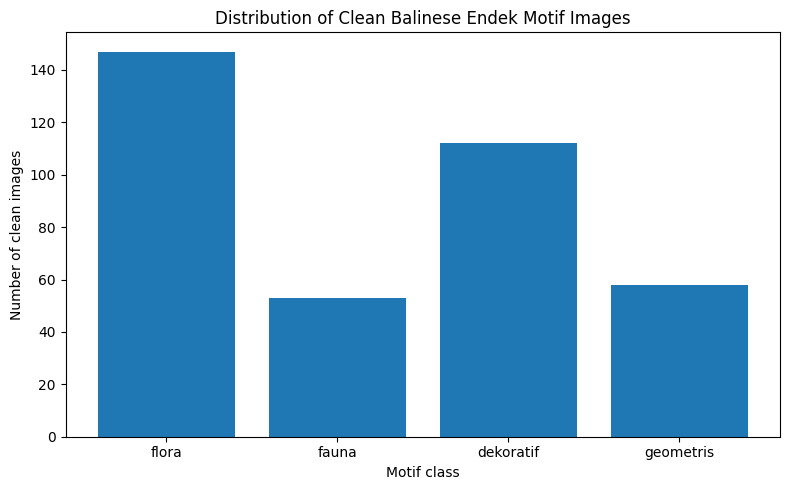

Saved: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\figures\fig_dataset_class_distribution.png


In [12]:
# ============================================================
# 11. Plot dataset distribution
# ============================================================
plot_df = distribution_df[distribution_df["class"] != "Total"].copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["class"], plot_df["clean_images_no_duplicate"])
plt.xlabel("Motif class")
plt.ylabel("Number of clean images")
plt.title("Distribution of Clean Balinese Endek Motif Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_dataset_class_distribution.png", dpi=300)
plt.show()

print("Saved:", FIG_DIR / "fig_dataset_class_distribution.png")


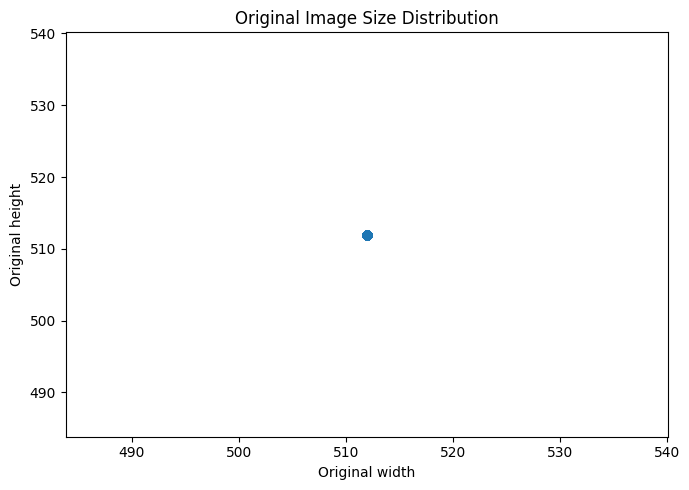

Saved: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\figures\fig_image_size_scatter.png


In [13]:
# ============================================================
# 12. Plot image dimension distribution
# ============================================================
if len(clean_df) > 0:
    plt.figure(figsize=(7, 5))
    plt.scatter(clean_df["width"], clean_df["height"], alpha=0.7)
    plt.xlabel("Original width")
    plt.ylabel("Original height")
    plt.title("Original Image Size Distribution")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_image_size_scatter.png", dpi=300)
    plt.show()
    print("Saved:", FIG_DIR / "fig_image_size_scatter.png")


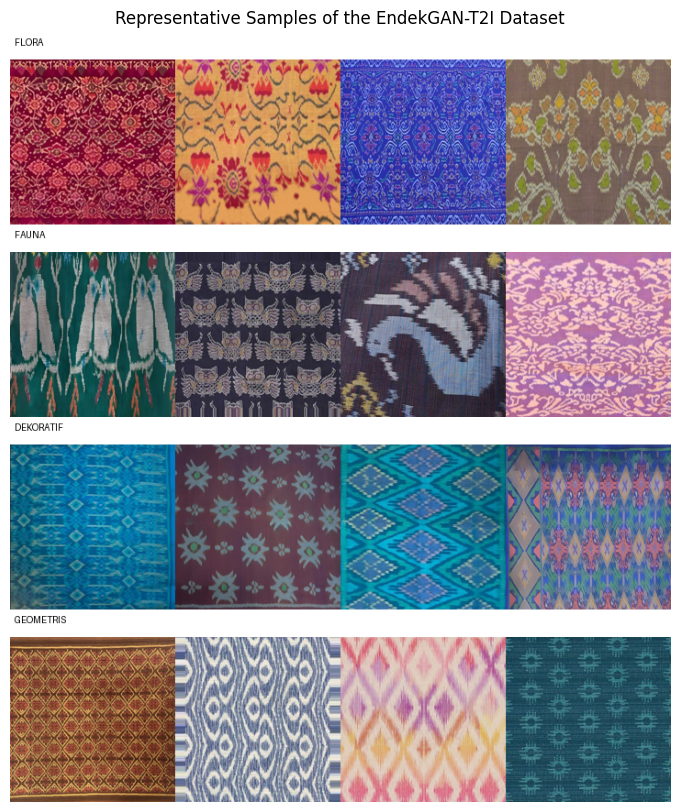

Saved: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\figures\fig_dataset_sample_grid.png


In [14]:
# ============================================================
# 13. Create sample grid per class
# ============================================================
def make_sample_grid(dataframe, n_per_class=4, thumb_size=180, seed=42):
    from PIL import Image, ImageDraw

    selected = []
    for label in CLASS_NAMES:
        sub = dataframe[dataframe["label"] == label].copy()
        if len(sub) == 0:
            continue
        sample = sub if len(sub) <= n_per_class else sub.sample(n=n_per_class, random_state=seed)
        selected.append(sample)

    if not selected:
        print("No images selected.")
        return None

    selected_df = pd.concat(selected, ignore_index=True)
    rows = len(CLASS_NAMES)
    cols = n_per_class
    canvas_w = cols * thumb_size
    canvas_h = rows * (thumb_size + 30)
    canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
    draw = ImageDraw.Draw(canvas)

    y = 0
    for label in CLASS_NAMES:
        sub = selected_df[selected_df["label"] == label].head(n_per_class)
        x = 0
        draw.text((5, y + 5), label.upper(), fill=(0, 0, 0))
        for _, row in sub.iterrows():
            try:
                img = Image.open(row["image_path"]).convert("RGB")
                img.thumbnail((thumb_size, thumb_size))
                tile = Image.new("RGB", (thumb_size, thumb_size), "white")
                tile.paste(img, ((thumb_size - img.width) // 2, (thumb_size - img.height) // 2))
                canvas.paste(tile, (x, y + 30))
            except Exception:
                pass
            x += thumb_size
        y += thumb_size + 30

    return canvas

grid = make_sample_grid(clean_df, n_per_class=4, thumb_size=180, seed=SEED)
if grid is not None:
    grid_path = FIG_DIR / "fig_dataset_sample_grid.png"
    grid.save(grid_path)
    plt.figure(figsize=(12, 10))
    plt.imshow(grid)
    plt.axis("off")
    plt.title("Representative Samples of the EndekGAN-T2I Dataset")
    plt.show()
    print("Saved:", grid_path)


In [15]:
# ============================================================
# 14. Stratified train/validation/test split
# ============================================================
if SKLEARN_AVAILABLE:
    train_df, temp_df = train_test_split(
        metadata_df,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=SEED,
        stratify=metadata_df["label"] if metadata_df["label"].nunique() > 1 else None
    )
    val_ratio_from_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1.0 - val_ratio_from_temp),
        random_state=SEED,
        stratify=temp_df["label"] if temp_df["label"].nunique() > 1 else None
    )
else:
    metadata_shuffled = metadata_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n = len(metadata_shuffled)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    train_df = metadata_shuffled.iloc[:n_train]
    val_df = metadata_shuffled.iloc[n_train:n_train+n_val]
    test_df = metadata_shuffled.iloc[n_train+n_val:]

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(METADATA_DIR / "train_split.csv", index=False, encoding="utf-8")
val_df.to_csv(METADATA_DIR / "val_split.csv", index=False, encoding="utf-8")
test_df.to_csv(METADATA_DIR / "test_split.csv", index=False, encoding="utf-8")

split_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "train": train_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).values,
    "validation": val_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).values,
    "test": test_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).values,
})
split_table.loc[len(split_table)] = {
    "class": "Total",
    "train": int(split_table["train"].sum()),
    "validation": int(split_table["validation"].sum()),
    "test": int(split_table["test"].sum()),
}
split_table.to_csv(TABLE_DIR / "table_dataset_split.csv", index=False, encoding="utf-8")
display(split_table)
print("Saved split files to:", METADATA_DIR)


,class,train,validation,test
0,flora,118,15,14
1,fauna,42,5,6
2,dekoratif,90,11,11
3,geometris,46,6,6
4,Total,296,37,37


Saved split files to: D:\DISERTASI_S3\WIWIK\DATASET_L2\EndekGAN\EndekGAN_Dataset\dataset_method_outputs_20260609_181013\metadata


In [16]:
# ============================================================
# 15. Export a concise dataset summary for Method section
# ============================================================
summary = {
    "dataset_root": str(DATASET_ROOT),
    "classes": CLASS_NAMES,
    "total_raw_images": int(len(raw_df)),
    "total_valid_images": int(len(valid_df)),
    "total_bad_images": int(len(bad_df)),
    "duplicate_files_by_md5": int(len(duplicate_df)),
    "total_clean_images_no_md5_duplicates": int(len(clean_df)),
    "unique_prompts": int(metadata_df["prompt"].nunique()),
    "train_images": int(len(train_df)),
    "validation_images": int(len(val_df)),
    "test_images": int(len(test_df)),
    "class_distribution_clean": clean_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).to_dict(),
    "split_distribution": {
        "train": train_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).to_dict(),
        "validation": val_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).to_dict(),
        "test": test_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0).astype(int).to_dict(),
    },
    "output_dir": str(OUTPUT_DIR),
}

summary_path = OUTPUT_DIR / "dataset_method_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print("Saved:", summary_path)


{
  "dataset_root": "D:\\DISERTASI_S3\\WIWIK\\DATASET_L2\\EndekGAN\\EndekGAN_Dataset",
  "classes": [
    "flora",
    "fauna",
    "dekoratif",
    "geometris"
  ],
  "total_raw_images": 372,
  "total_valid_images": 372,
  "total_bad_images": 0,
  "duplicate_files_by_md5": 4,
  "total_clean_images_no_md5_duplicates": 370,
  "unique_prompts": 369,
  "train_images": 296,
  "validation_images": 37,
  "test_images": 37,
  "class_distribution_clean": {
    "flora": 147,
    "fauna": 53,
    "dekoratif": 112,
    "geometris": 58
  },
  "split_distribution": {
    "train": {
      "flora": 118,
      "fauna": 42,
      "dekoratif": 90,
      "geometris": 46
    },
    "validation": {
      "flora": 15,
      "fauna": 5,
      "dekoratif": 11,
      "geometris": 6
    },
    "test": {
      "flora": 14,
      "fauna": 6,
      "dekoratif": 11,
      "geometris": 6
    }
  },
  "output_dir": "D:\\DISERTASI_S3\\WIWIK\\DATASET_L2\\EndekGAN\\EndekGAN_Dataset\\dataset_method_outputs_20260609_18101

In [17]:
# ============================================================
# 16. Generate plain-text draft for Dataset subsection
# ============================================================
class_dist_text = ", ".join([
    f"{cls}: {summary['class_distribution_clean'][cls]}"
    for cls in CLASS_NAMES
])

dataset_text = (
    "Dataset Subsection Draft\n\n"
    "The EndekGAN-T2I dataset was organized as a four-class Balinese Endek motif collection "
    "consisting of flora, fauna, decorative, and geometric categories. The image files were "
    "stored in class-specific folders under the dataset root directory and were automatically "
    "scanned using a reproducible Python pipeline. "
    f"The initial scan identified {summary['total_raw_images']} image files, of which "
    f"{summary['total_valid_images']} were readable RGB images and {summary['total_bad_images']} "
    "were unreadable or corrupted files. "
    "Exact duplicate detection was performed using MD5 hashing, resulting in "
    f"{summary['duplicate_files_by_md5']} duplicate-file entries and "
    f"{summary['total_clean_images_no_md5_duplicates']} clean images after duplicate removal. "
    f"The final class distribution was {class_dist_text}.\n\n"
    "To support text-to-image conditioning, each clean image was paired with an expert-guided "
    "textual prompt. The prompt construction was derived from Endek design knowledge, including "
    "motif class, motif source, stylization/deformation/distortion technique, layout pattern, "
    "composition principle, colour tendency, cultural context, and weavability constraint. "
    f"This procedure produced {summary['unique_prompts']} unique expert-guided prompts for the clean dataset. "
    f"The dataset was then split into training, validation, and test subsets using an "
    f"{int(TRAIN_RATIO*100)}:{int(VAL_RATIO*100)}:{int(TEST_RATIO*100)} ratio with a fixed random seed of {SEED}. "
    f"The resulting split contained {summary['train_images']} training images, "
    f"{summary['validation_images']} validation images, and {summary['test_images']} test images."
)

print(dataset_text)

draft_path = OUTPUT_DIR / "dataset_subsection_draft.txt"
with open(draft_path, "w", encoding="utf-8") as f:
    f.write(dataset_text)

print("Saved:", draft_path)


Dataset Subsection Draft

The EndekGAN-T2I dataset was organized as a four-class Balinese Endek motif collection consisting of flora, fauna, decorative, and geometric categories. The image files were stored in class-specific folders under the dataset root directory and were automatically scanned using a reproducible Python pipeline. The initial scan identified 372 image files, of which 372 were readable RGB images and 0 were unreadable or corrupted files. Exact duplicate detection was performed using MD5 hashing, resulting in 4 duplicate-file entries and 370 clean images after duplicate removal. The final class distribution was flora: 147, fauna: 53, dekoratif: 112, geometris: 58.

To support text-to-image conditioning, each clean image was paired with an expert-guided textual prompt. The prompt construction was derived from Endek design knowledge, including motif class, motif source, stylization/deformation/distortion technique, layout pattern, composition principle, colour tendency, 

## Output files for paper

Setelah notebook dijalankan, file penting berada pada:

```text
dataset_method_outputs_<RUN_ID>/
├── figures/
│   ├── fig_dataset_class_distribution.png
│   ├── fig_image_size_scatter.png
│   └── fig_dataset_sample_grid.png
├── tables/
│   ├── table_dataset_distribution.csv
│   ├── table_image_size_summary.csv
│   ├── table_prompt_technique_distribution.csv
│   ├── table_prompt_layout_distribution.csv
│   └── table_dataset_split.csv
├── metadata/
│   ├── metadata_expert_guided.csv
│   ├── train_split.csv
│   ├── val_split.csv
│   └── test_split.csv
├── dataset_method_summary.json
└── dataset_subsection_draft.txt
```
